## Plot Seismological Signal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal

ModuleNotFoundError: No module named 'numpy'

In [3]:
data = pd.read_csv("new_data.txt", delimiter="\t")
data.head()

,Time (s),V,E-W,N-S
0,0.005061,0.000000,0.000000,0.000000
1,0.013118,0.108196,-0.028693,-0.083390
2,0.021083,0.126059,-0.061575,-0.100002
3,0.029078,0.174420,-0.028146,-0.041631
4,0.037043,0.154688,0.009908,0.015546


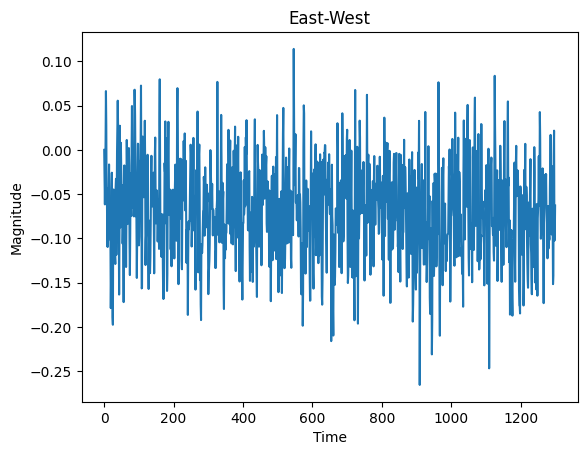

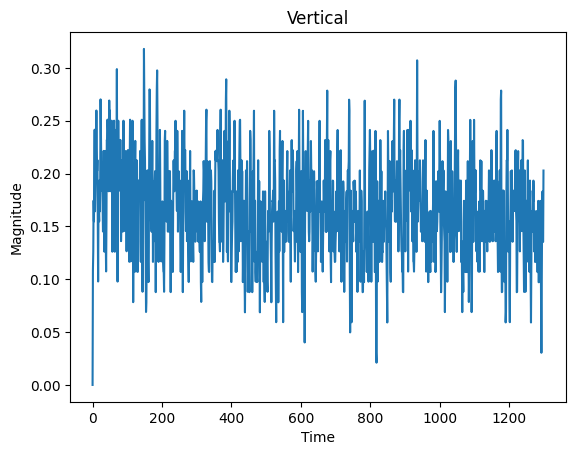

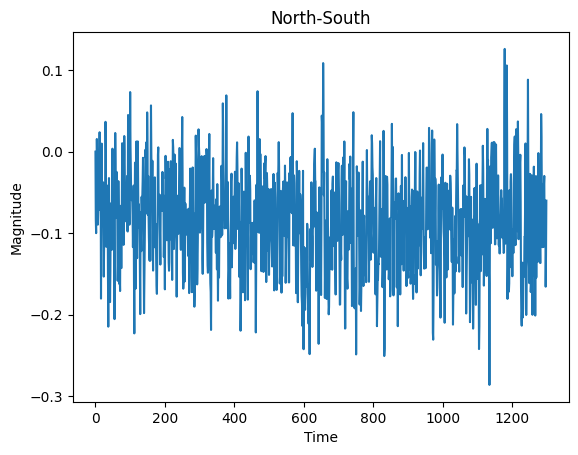

In [4]:
plt.plot(data["E-W"])
plt.title("East-West")
plt.ylabel("Magnitude")
plt.xlabel("Time")
plt.show()

# Vertical
plt.plot(data["V"])
plt.title("Vertical")
plt.ylabel("Magnitude")
plt.xlabel("Time")
plt.show()

# North-South
plt.plot(data["N-S"])
plt.title("North-South")
plt.ylabel("Magnitude")
plt.xlabel("Time")
plt.show()

### Neutralize the signal

In [5]:
data["V"] = data["V"] - np.mean(data["V"])
data["E-W"] = data["E-W"] - np.mean(data["E-W"])
data["N-S"] = data["N-S"] - np.mean(data["N-S"])

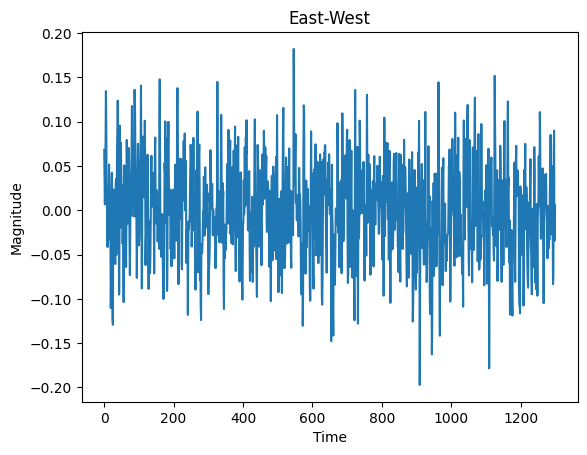

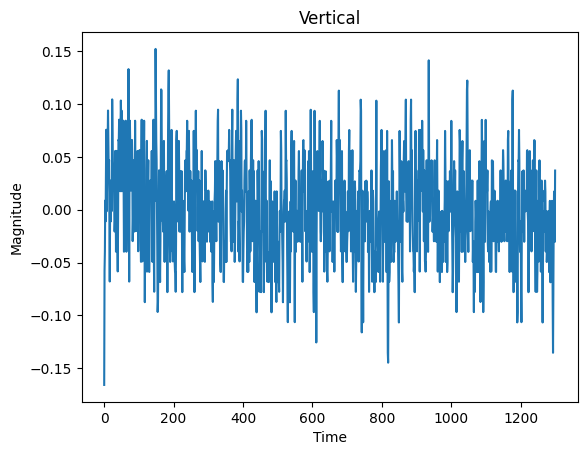

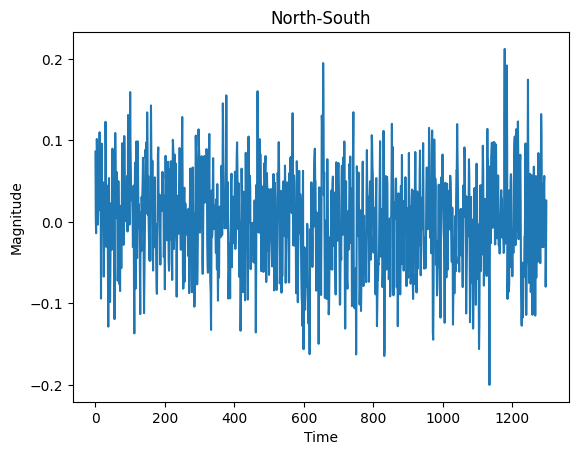

In [6]:
plt.plot(data["E-W"])
plt.title("East-West")
plt.ylabel("Magnitude")
plt.xlabel("Time")
plt.show()

# Vertical
plt.plot(data["V"])
plt.title("Vertical")
plt.ylabel("Magnitude")
plt.xlabel("Time")
plt.show()

# North-South
plt.plot(data["N-S"])
plt.title("North-South")
plt.ylabel("Magnitude")
plt.xlabel("Time")
plt.show()

## Detrend the signal

In [10]:
detrended_v_signal = signal.detrend(data["V"])
detrended_e_w_signal = signal.detrend(data["E-W"])
detrended_n_s_signal = signal.detrend(data["N-S"])

detrended_v_signal

array([-0.17741398, -0.06920026, -0.05131944, ..., -0.01842027,
       -0.01892076,  0.04860932], shape=(1300,))

## Fourier Transform

Sampling frequency: 125.31 Hz


/var/folders/09/jyvyjd097mg1kj_vr6ptdp7c0000gn/T/ipykernel_74589/3506208170.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


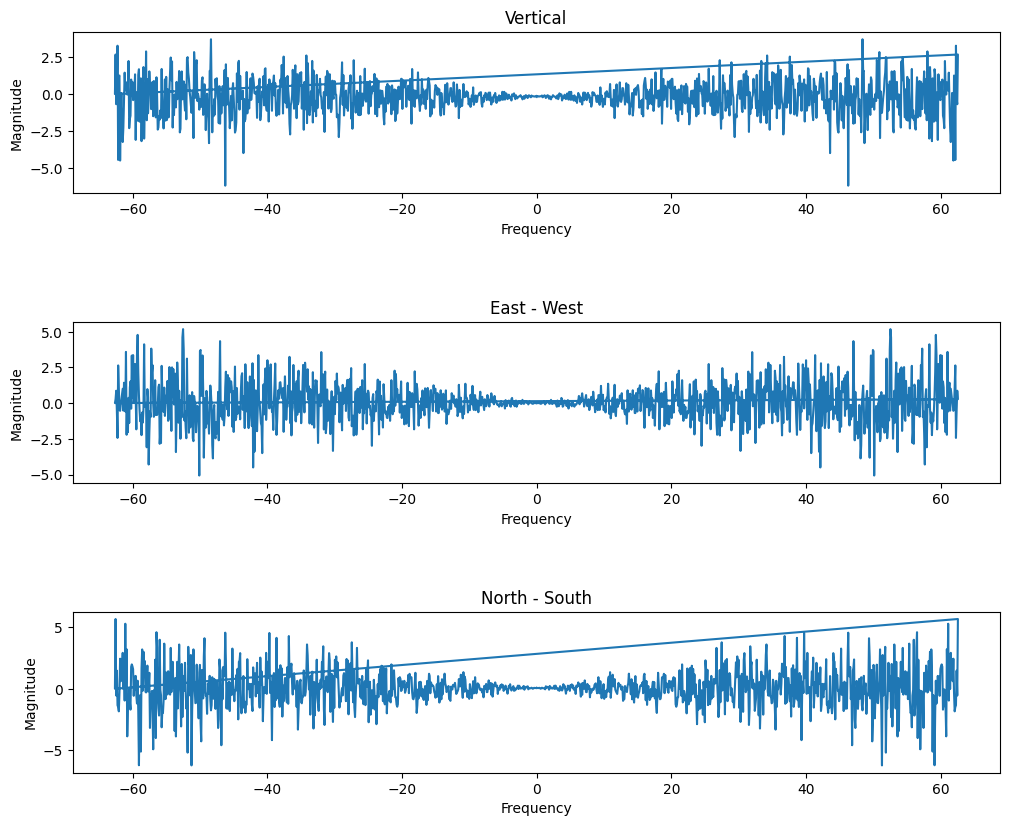

In [18]:
# Create a figure with proper spacing first
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.tight_layout()
fig.subplots_adjust(hspace=0.8)  # Increase vertical spacing between plots

# Assuming you have these variables defined
# detrended_v_signal, detrended_e_w_signal, detrended_n_s_signal

# Calculate FFTs
v_fft = np.fft.fft(detrended_v_signal)
e_w_fft = np.fft.fft(detrended_e_w_signal)
n_s_fft = np.fft.fft(detrended_n_s_signal)

time = data["Time (s)"]
# Calculate sampling rate from time data
dt = np.mean(np.diff(time))  # Average time step
fs = 1.0 / dt  # Sampling frequency in Hz
print(f"Sampling frequency: {fs:.2f} Hz")

n = len(v_fft)
freqs = np.fft.fftfreq(n, d=dt)

# Shift the FFT data to match the shifted frequencies
v_fft_shifted = np.fft.fftshift(v_fft)
e_w_fft_shifted = np.fft.fftshift(e_w_fft)
n_s_fft_shifted = np.fft.fftshift(n_s_fft)

# Vertical fft plot
axes[0].plot(freqs, np.real(v_fft_shifted))
axes[0].set_title("Vertical")
axes[0].set_ylabel("Magnitude")
axes[0].set_xlabel("Frequency")

# East West fft plot
axes[1].plot(freqs, np.real(e_w_fft_shifted))
axes[1].set_title("East - West")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlabel("Frequency")

# North South fft plot
axes[2].plot(freqs, np.real(n_s_fft_shifted))
axes[2].set_title("North - South")
axes[2].set_ylabel("Magnitude")
axes[2].set_xlabel("Frequency")

fig.show()

## Save it to the file

In [12]:
n = len(v_fft)
freqs = np.fft.fftshift(np.fft.fftfreq(n))

# Shift the FFT data to match the shifted frequencies
v_fft_shifted = np.fft.fftshift(v_fft)
e_w_fft_shifted = np.fft.fftshift(e_w_fft)
n_s_fft_shifted = np.fft.fftshift(n_s_fft)

# Create a DataFrame with the data
df = pd.DataFrame(
    {
        "Frequency": freqs,
        "Vertical_Real": np.real(v_fft_shifted),
        "Vertical_Imag": np.imag(v_fft_shifted),
        "Vertical_Magnitude": np.abs(v_fft_shifted),
        "EastWest_Real": np.real(e_w_fft_shifted),
        "EastWest_Imag": np.imag(e_w_fft_shifted),
        "EastWest_Magnitude": np.abs(e_w_fft_shifted),
        "NorthSouth_Real": np.real(n_s_fft_shifted),
        "NorthSouth_Imag": np.imag(n_s_fft_shifted),
        "NorthSouth_Magnitude": np.abs(n_s_fft_shifted),
    }
)

# Save to CSV
df.to_csv("fft_data.csv", index=False)
print("FFT data saved")

FFT data saved
